# FD001 exploratory analysis

This notebook profiles the training data. Feature decisions use development engines only (`unit_id % 5 != 0`) so the fixed validation partition remains isolated.

In [1]:
from pathlib import Path
from src.data.ingest import load_fd001_file

train = load_fd001_file(Path('../data/raw/train_FD001.txt'))
development = train[train['unit_id'] % 5 != 0].copy()
validation = train[train['unit_id'] % 5 == 0].copy()


In [2]:
lifecycle_lengths = development.groupby('unit_id')['cycle'].max()
summary = {
    'development_rows': int(len(development)),
    'development_engines': int(development['unit_id'].nunique()),
    'validation_rows': int(len(validation)),
    'validation_engines': int(validation['unit_id'].nunique()),
    'lifecycle_min': int(lifecycle_lengths.min()),
    'lifecycle_median': float(lifecycle_lengths.median()),
    'lifecycle_max': int(lifecycle_lengths.max()),
}
summary


{'development_rows': 16656,
 'development_engines': 80,
 'validation_rows': 3975,
 'validation_engines': 20,
 'lifecycle_min': 128,
 'lifecycle_median': 199.5,
 'lifecycle_max': 362}

The development partition contains 80 engines and is the only partition used for exploratory feature decisions. The 20 validation engines remain reserved for later model evaluation.

In [5]:
import matplotlib.pyplot as plt
import numpy as np

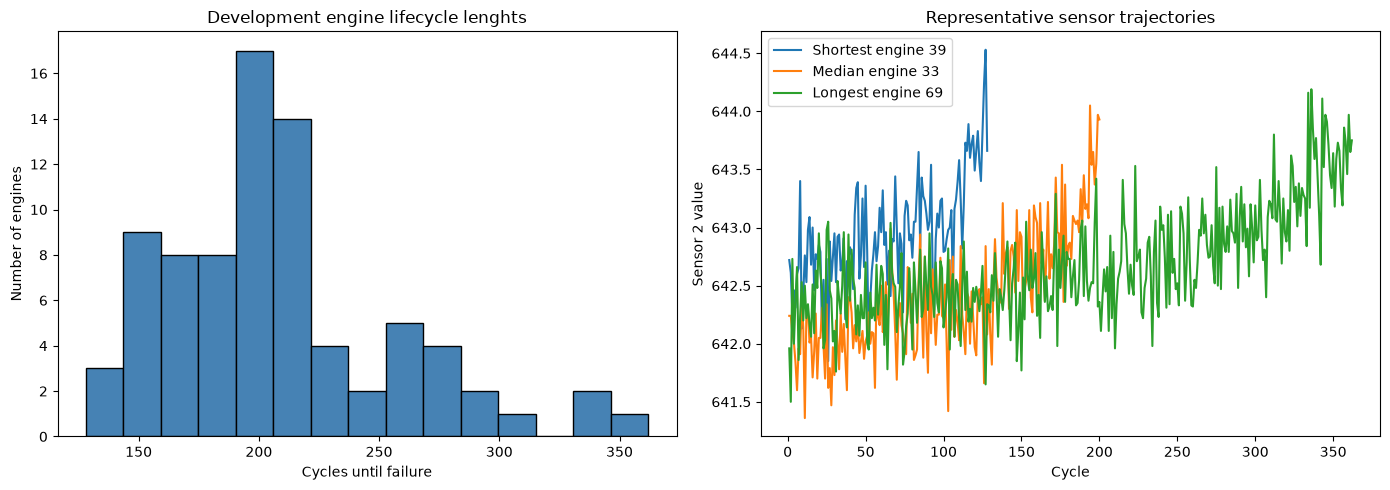

In [10]:
lifecycle_lengths = (
    development.groupby("unit_id")["cycle"]
    .max()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    lifecycle_lengths,
    bins=15,
    color="steelblue",
    edgecolor="black",
)
axes[0].set_title("Development engine lifecycle lenghts")
axes[0].set_xlabel("Cycles until failure")
axes[0].set_ylabel("Number of engines")

selected_engines = {
    "Shortest": lifecycle_lengths.idxmin(),
    "Median": lifecycle_lengths.sort_values().index[len(lifecycle_lengths) // 2],
    "Longest": lifecycle_lengths.idxmax(),
}

for label, unit_id in selected_engines.items():
    engine = development[development["unit_id"] == unit_id]

    axes[1].plot(
        engine["cycle"],
        engine["sensor_2"],
        label=f"{label} engine {unit_id}",
    )

axes[1].set_title("Representative sensor trajectories")
axes[1].set_xlabel("Cycle")
axes[1].set_ylabel("Sensor 2 value")
axes[1].legend()

plt.tight_layout()
plt.show()

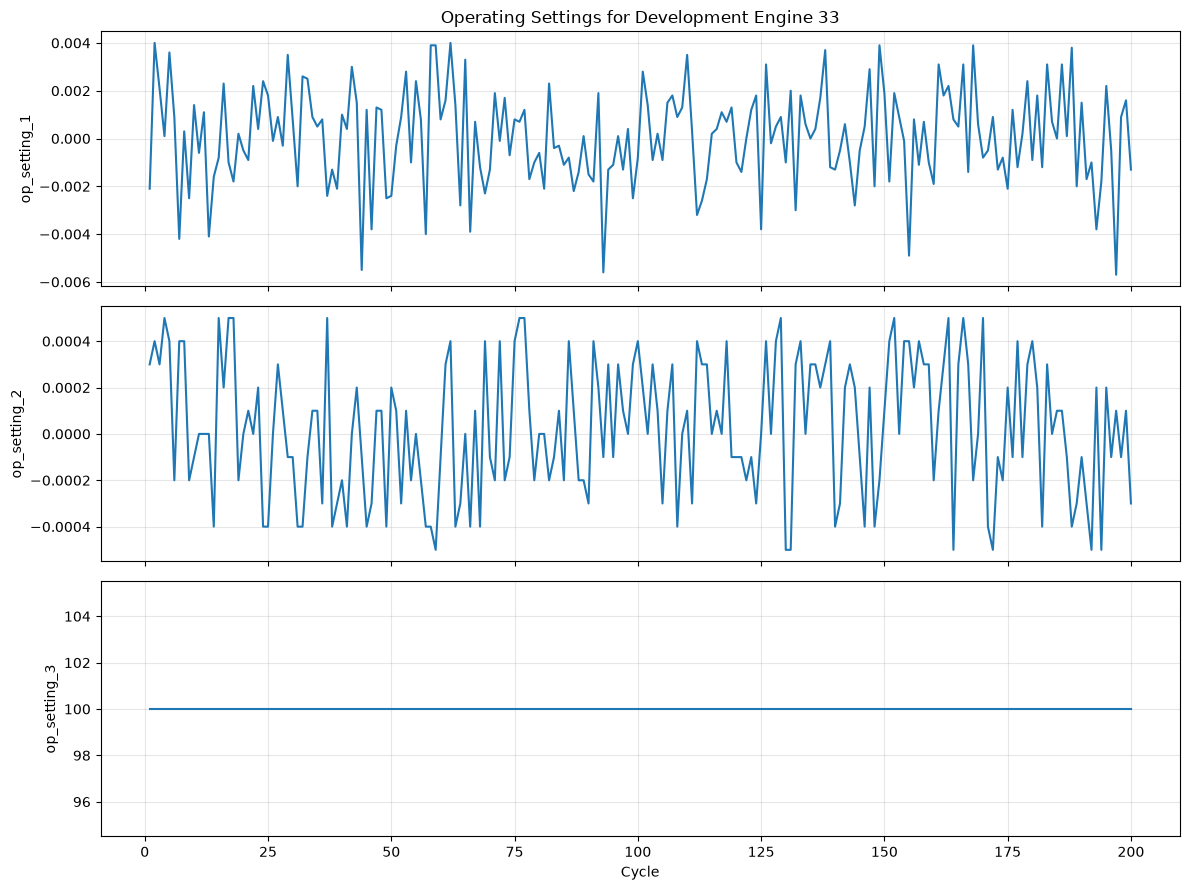

In [11]:
median_unit_id = selected_engines["Median"]

median_engine = development[
    development["unit_id"] == median_unit_id
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(12, 9),
    sharex=True,
)

setting_columns = [
    "op_setting_1",
    "op_setting_2",
    "op_setting_3",
]

for axis, setting in zip(axes, setting_columns):
    axis.plot(
        median_engine["cycle"],
        median_engine[setting],
    )
    axis.set_ylabel(setting)
    axis.grid(alpha=0.3)

axes[0].set_title(
    f"Operating Settings for Development Engine {median_unit_id}"
)
axes[-1].set_xlabel("Cycle")

plt.tight_layout()
plt.show()

In [13]:
sensor_columns = [
    column
    for column in development.columns
    if column.startswith("sensor_")
]

sensor_variance = (
    development[sensor_columns]
    .var(ddof=0)
    .sort_values()
)

constant_sensors = sensor_variance[
    sensor_variance == 0
].index.tolist()

near_constant_threshold = 1e-6

near_constant_sensors = sensor_variance[
    sensor_variance <= near_constant_threshold
].index.tolist()

print("Sensor variance:")
display(sensor_variance)

print("Constant sensors:")
display(constant_sensors)

print("Near-constant sensors:")
print(near_constant_sensors)

Sensor variance:


sensor_1     0.000000e+00
sensor_18    0.000000e+00
sensor_19    0.000000e+00
sensor_16    1.083336e-34
sensor_10    4.930381e-32
sensor_5     3.155444e-30
sensor_6     1.872771e-06
sensor_15    1.408790e-03
sensor_8     5.118366e-03
sensor_13    5.198681e-03
sensor_21    1.170943e-02
sensor_20    3.262228e-02
sensor_11    7.119812e-02
sensor_2     2.476946e-01
sensor_12    5.449766e-01
sensor_7     7.806017e-01
sensor_17    2.391359e+00
sensor_3     3.739800e+01
sensor_4     8.050732e+01
sensor_14    3.797867e+02
sensor_9     5.057468e+02
dtype: float64

Constant sensors:


['sensor_1', 'sensor_18', 'sensor_19']

Near-constant sensors:
['sensor_1', 'sensor_18', 'sensor_19', 'sensor_16', 'sensor_10', 'sensor_5']


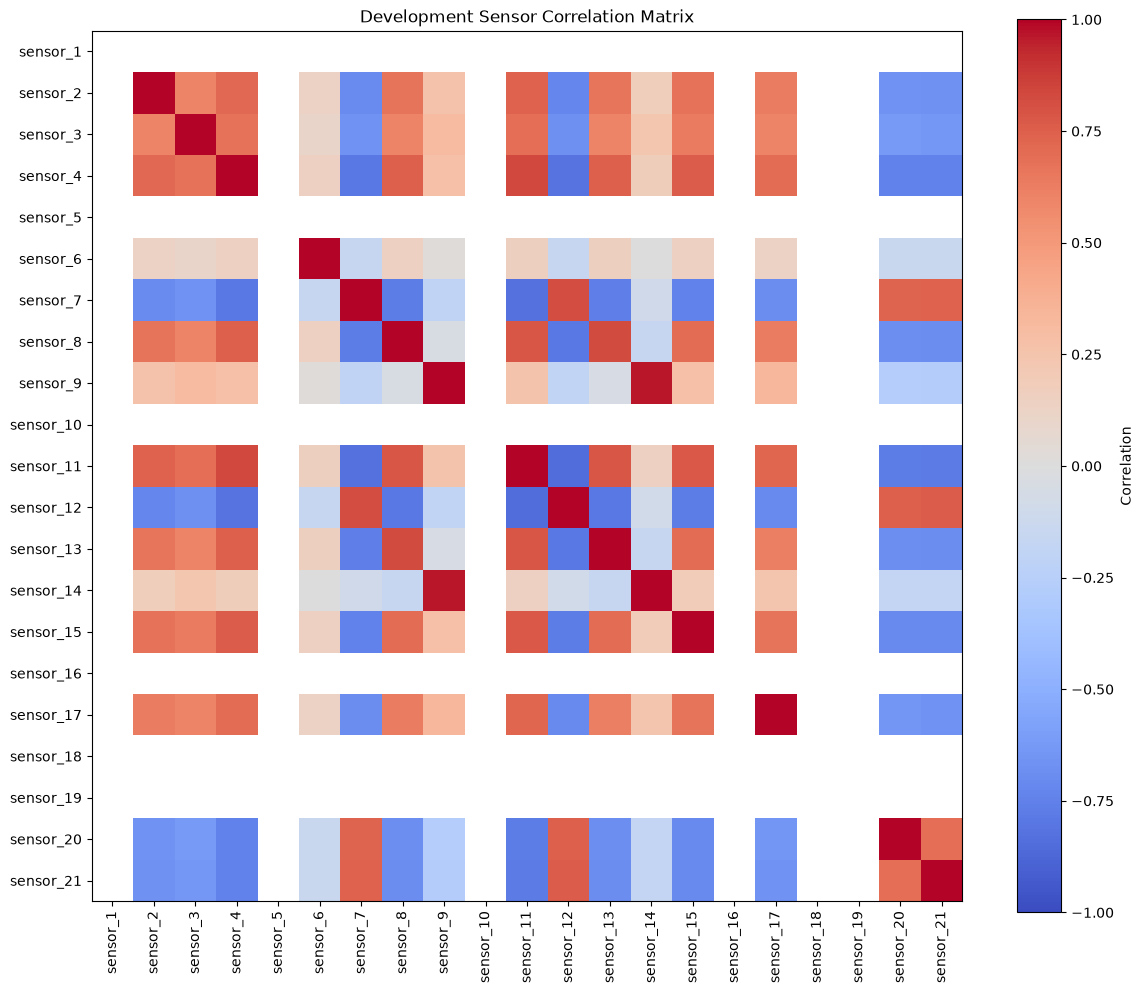

In [15]:
correlation_matrix = development[sensor_columns].corr()

fig, axis = plt.subplots(
    figsize=(12,10)
)

image = axis.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)

axis.set_title("Development Sensor Correlation Matrix")
axis.set_xticks(range(len(sensor_columns)))
axis.set_yticks(range(len(sensor_columns)))
axis.set_xticklabels(sensor_columns, rotation=90)
axis.set_yticklabels(sensor_columns)

fig.colorbar(
    image,
    ax=axis,
    label="Correlation",
)

plt.tight_layout()
plt.show()

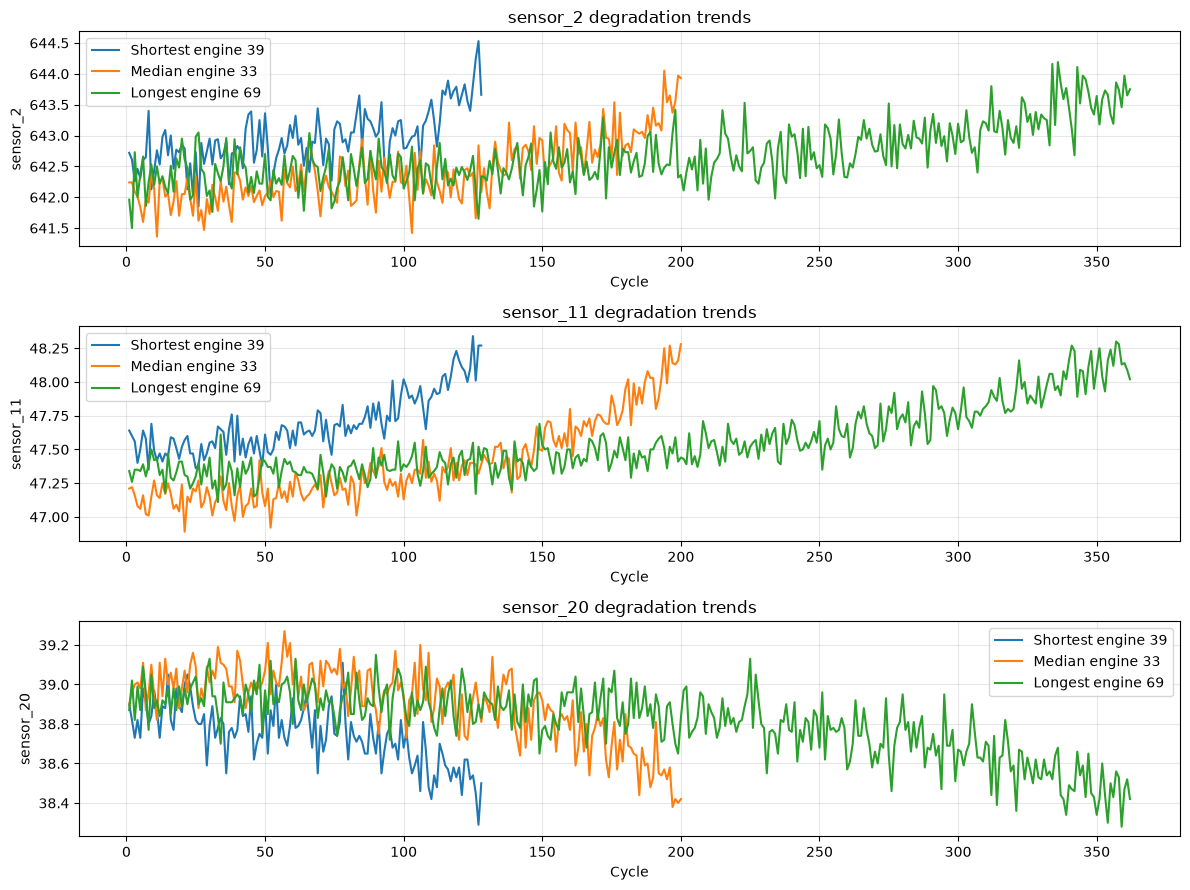

In [16]:
trend_sensors = [
    "sensor_2",
    "sensor_11",
    "sensor_20",
]

fig, axes = plt.subplots(
    nrows=len(trend_sensors),
    ncols=1,
    figsize=(12, 9),
    sharex=False,
)

for axis, sensor in zip(axes, trend_sensors):
    for label, unit_id in selected_engines.items():
        engine = development[
            development["unit_id"] == unit_id
        ]

        axis.plot(
            engine["cycle"],
            engine[sensor],
            label=f"{label} engine {unit_id}",
        )

    axis.set_title(f"{sensor} degradation trends")
    axis.set_xlabel("Cycle")
    axis.set_ylabel(sensor)
    axis.legend()
    axis.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
import json
from pathlib import Path

In [18]:
excluded_features = sorted(near_constant_sensors)

excluded_features_path = Path(
    "../configs/excluded_features.json"
)

excluded_features_path.write_text(
    json.dumps(
        {
            "feature_selection_partition": "development",
            "variance_threshold": near_constant_threshold,
            "excluded_features": excluded_features,
        },
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)

print(f"Saved {len(excluded_features)} excluded features:")
print(excluded_features)

Saved 6 excluded features:
['sensor_1', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19', 'sensor_5']
